# Stage1→Stage2 성능 하락 원인 분석 (E1→E3)

E8 ablation 결과: **새 loss(plan/ego)가 det/map 성능 하락의 직접 원인**임을 확인함.
이제 메커니즘을 분류:

| # | 메커니즘 | 측정 방법 | 해법 |
|---|---------|----------|------|
| 1 | **Gradient Conflict** (방향 충돌) | `cos(g_i, g_j) < 0` | PCGrad, CAGrad, FAMO |
| 2 | **Gradient Domination** (크기 압도) | `‖g_plan‖ / ‖g_det‖` | Loss reweighting, GradNorm |
| 3 | **Representation Drift** (feature 변화) | feature cosine before/after update | LwF, L2-SP, EWC |

- **체크포인트**: E1 stage1 최종 (stage2 학습 전) + E3 iter_2344 (stage2 1ep 후)
- **배치 수**: 설정 가능 (default 20)

In [1]:
import os, sys, torch, numpy as np
import torch.nn.functional as F
from collections import defaultdict
from tqdm import tqdm

# ===================== CONFIG =====================
os.environ['CUDA_VISIBLE_DEVICES'] = '2,3'
GPU_ID = 0
NUM_BATCHES = 20

PROJECT_ROOT = '/home/kyungmin/min_ws/rideflux/HiP-AD'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# E3 stage2 config (모델 구조 정의)
STAGE2_CONFIG = 'projects/configs/experiments/E3_E1_stage2_6ep.py'
# E1 stage1 최종 ckpt (stage2 학습 전)
E1_CKPT = './work_dirs/exp/E1_stage1_12ep/latest.pth'
# E3 1 epoch ckpt (stage2 학습 후 비교용)
E3_1EP_CKPT = './work_dirs/exp/E3_E1_stage2_6ep/iter_2344.pth'

CKPTS = {
    'E1_stage1_final': E1_CKPT,
    'E3_stage2_1ep': E3_1EP_CKPT,
}

from mmcv import Config
from mmcv.runner import load_checkpoint, wrap_fp16_model
from mmcv.parallel.scatter_gather import scatter_kwargs
from mmdet.models import build_detector
from mmdet.datasets import build_dataset, build_dataloader as build_dataloader_origin
import importlib
importlib.import_module('projects.mmdet3d_plugin')

print(f"GPU: {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")
print(f"Batches: {NUM_BATCHES}")

/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


Use flash_attn_varlen_kvpacked_func
GPU: 2x NVIDIA GeForce RTX 4090
Batches: 20


In [9]:
# ===================== 유틸리티 함수 =====================

TASK_LOSS_PREFIXES = {
    'det': ['det_loss'],
    'map': ['map_loss'],
    'motion': ['motion_loss'],
    'ego': ['ego_loss'],
    'plan': ['plan_loss'],
}

PARAM_GROUPS = {
    'backbone': lambda n: n.startswith('img_backbone'),
    'neck': lambda n: n.startswith('img_neck'),
    'shared_decoder': lambda n: 'onedecoder_head.layers.' in n,
    'det_specific': lambda n: any(k in n for k in ['det_instance_bank', 'det_anchor_encoder', 'det_deformable', 'det_refine']),
    'map_specific': lambda n: any(k in n for k in ['map_instance_bank', 'map_anchor_encoder', 'map_deformable', 'map_refine']),
    'plan_specific': lambda n: any(k in n for k in ['plan_instance_bank', 'plan_anchor_encoder', 'plan_deformable', 'plan_refine', 'ego_instance_bank', 'ego_deformable', 'ego_refine']),
}


def build_model_and_loader(ckpt_path):
    cfg = Config.fromfile(STAGE2_CONFIG)
    cfg.model.pretrained = None
    model = build_detector(cfg.model, train_cfg=cfg.get("train_cfg"), test_cfg=cfg.get("test_cfg"))
    fp16_cfg = cfg.get("fp16", None)
    if fp16_cfg is not None:
        wrap_fp16_model(model)
    load_checkpoint(model, ckpt_path, map_location="cpu")
    model.train()
    model = model.cuda(GPU_ID)

    dataset = build_dataset(cfg.data.train)
    loader = build_dataloader_origin(dataset, samples_per_gpu=1, workers_per_gpu=4, dist=False, shuffle=True)
    return model, loader


def group_losses_by_task(losses_dict):
    task_total = {}
    for task, prefixes in TASK_LOSS_PREFIXES.items():
        vals = [v for k, v in losses_dict.items()
                if isinstance(v, torch.Tensor) and any(k.startswith(p) for p in prefixes)]
        if vals:
            task_total[task] = sum(vals)
    return task_total


def get_params_by_group(model, group_name):
    filter_fn = PARAM_GROUPS[group_name]
    params = [(n, p) for n, p in model.named_parameters() if filter_fn(n) and p.requires_grad]
    return [p for _, p in params], [n for n, _ in params]


def collect_task_gradients(model, losses_dict, target_params):
    """각 task loss에 대해 target_params의 gradient를 개별 계산"""
    task_losses = group_losses_by_task(losses_dict)
    task_grads = {}
    task_loss_vals = {}

    for task_name, task_loss in task_losses.items():
        model.zero_grad()
        task_loss.backward(retain_graph=True)
        grads = []
        for p in target_params:
            if p.grad is not None:
                grads.append(p.grad.detach().clone().flatten())
            else:
                grads.append(torch.zeros(p.numel(), device=p.device))
        task_grads[task_name] = torch.cat(grads)
        task_loss_vals[task_name] = task_loss.item()

    model.zero_grad()
    return task_grads, task_loss_vals


def forward_one_batch(model, loader_iter):
    data = next(loader_iter)
    _, scatter_kwargs_out = scatter_kwargs(inputs=None, kwargs=data, target_gpus=[GPU_ID])
    data_gpu = scatter_kwargs_out[0]
    img = data_gpu.pop('img')
    losses = model.forward_train(img.float(), **data_gpu)
    return losses, img, data_gpu


print("Utilities ready.")
print(f"Param groups: {list(PARAM_GROUPS.keys())}")

Utilities ready.
Param groups: ['backbone', 'neck', 'shared_decoder', 'det_specific', 'map_specific', 'plan_specific']


## 1. Gradient Conflict + Domination 분석

파라미터 그룹별 × 체크포인트별로:
- **Cosine similarity**: task pair 간 gradient 방향 충돌 여부
- **Gradient L2 norm**: task 간 크기 비율 (domination 여부)
- **Loss value**: 참고용

In [10]:
# ===================== 1. Conflict + Domination 측정 =====================

ANALYSIS_GROUPS = ['backbone', 'neck', 'shared_decoder']  # 공유 파라미터만

results = {}  # results[ckpt_name][group_name] = {cos_sims, grad_norms, loss_vals}

for ckpt_name, ckpt_path in CKPTS.items():
    print(f"\n{'='*70}")
    print(f"  Checkpoint: {ckpt_name}")
    print(f"{'='*70}")

    model, loader = build_model_and_loader(ckpt_path)
    loader_iter = iter(loader)
    results[ckpt_name] = {}

    for group_name in ANALYSIS_GROUPS:
        params, names = get_params_by_group(model, group_name)
        n_elements = sum(p.numel() for p in params)
        print(f"\n  [{group_name}] params={len(params)}, elements={n_elements:,}")

        cos_sims = defaultdict(list)
        grad_norms = defaultdict(list)
        loss_vals = defaultdict(list)

        loader_iter = iter(loader)  # 매 그룹마다 같은 배치 순서
        for b in tqdm(range(NUM_BATCHES), desc=f"  {group_name}"):
            try:
                losses, img, data_gpu = forward_one_batch(model, loader_iter)
            except StopIteration:
                break

            task_grads, task_loss_v = collect_task_gradients(model, losses, params)

            for task, lv in task_loss_v.items():
                loss_vals[task].append(lv)
            for task, grad in task_grads.items():
                grad_norms[task].append(grad.float().norm().item())

            tasks = sorted(task_grads.keys())
            for i in range(len(tasks)):
                for j in range(i + 1, len(tasks)):
                    gi = task_grads[tasks[i]].float()
                    gj = task_grads[tasks[j]].float()
                    cos = F.cosine_similarity(gi.unsqueeze(0), gj.unsqueeze(0)).item()
                    cos_sims[f"{tasks[i]} vs {tasks[j]}"].append(cos)

            del losses, task_grads, img, data_gpu
            torch.cuda.empty_cache()

        results[ckpt_name][group_name] = {
            'cos_sims': dict(cos_sims),
            'grad_norms': dict(grad_norms),
            'loss_vals': dict(loss_vals),
        }

    del model, loader
    torch.cuda.empty_cache()

print("\nDone.")


  Checkpoint: E1_stage1_final


/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '


load checkpoint from local path: ./work_dirs/exp/E1_stage1_12ep/latest.pth
The model and loaded state dict do not match exactly

missing keys in source state_dict: head.onedecoder_head.motion_anchor, head.onedecoder_head.motion_anchor_encoder.0.weight, head.onedecoder_head.motion_anchor_encoder.0.bias, head.onedecoder_head.motion_anchor_encoder.2.weight, head.onedecoder_head.motion_anchor_encoder.2.bias, head.onedecoder_head.motion_anchor_encoder.3.weight, head.onedecoder_head.motion_anchor_encoder.3.bias, head.onedecoder_head.motion_refine.0.motion_cls_branch.0.weight, head.onedecoder_head.motion_refine.0.motion_cls_branch.0.bias, head.onedecoder_head.motion_refine.0.motion_cls_branch.2.weight, head.onedecoder_head.motion_refine.0.motion_cls_branch.2.bias, head.onedecoder_head.motion_refine.0.motion_cls_branch.3.weight, head.onedecoder_head.motion_refine.0.motion_cls_branch.3.bias, head.onedecoder_head.motion_refine.0.motion_cls_branch.5.weight, head.onedecoder_head.motion_refine.0.mo

  backbone: 100%|██████████| 20/20 [00:37<00:00,  1.86s/it]


  [neck] params=20, elements=3,345,408


...


  [neck] params=20, elements=3,345,408



  neck: 100%|██████████| 20/20 [00:34<00:00,  1.74s/it]


  [shared_decoder] params=204, elements=22,873,088



  shared_decoder: 100%|██████████| 20/20 [00:37<00:00,  1.89s/it]


Done.


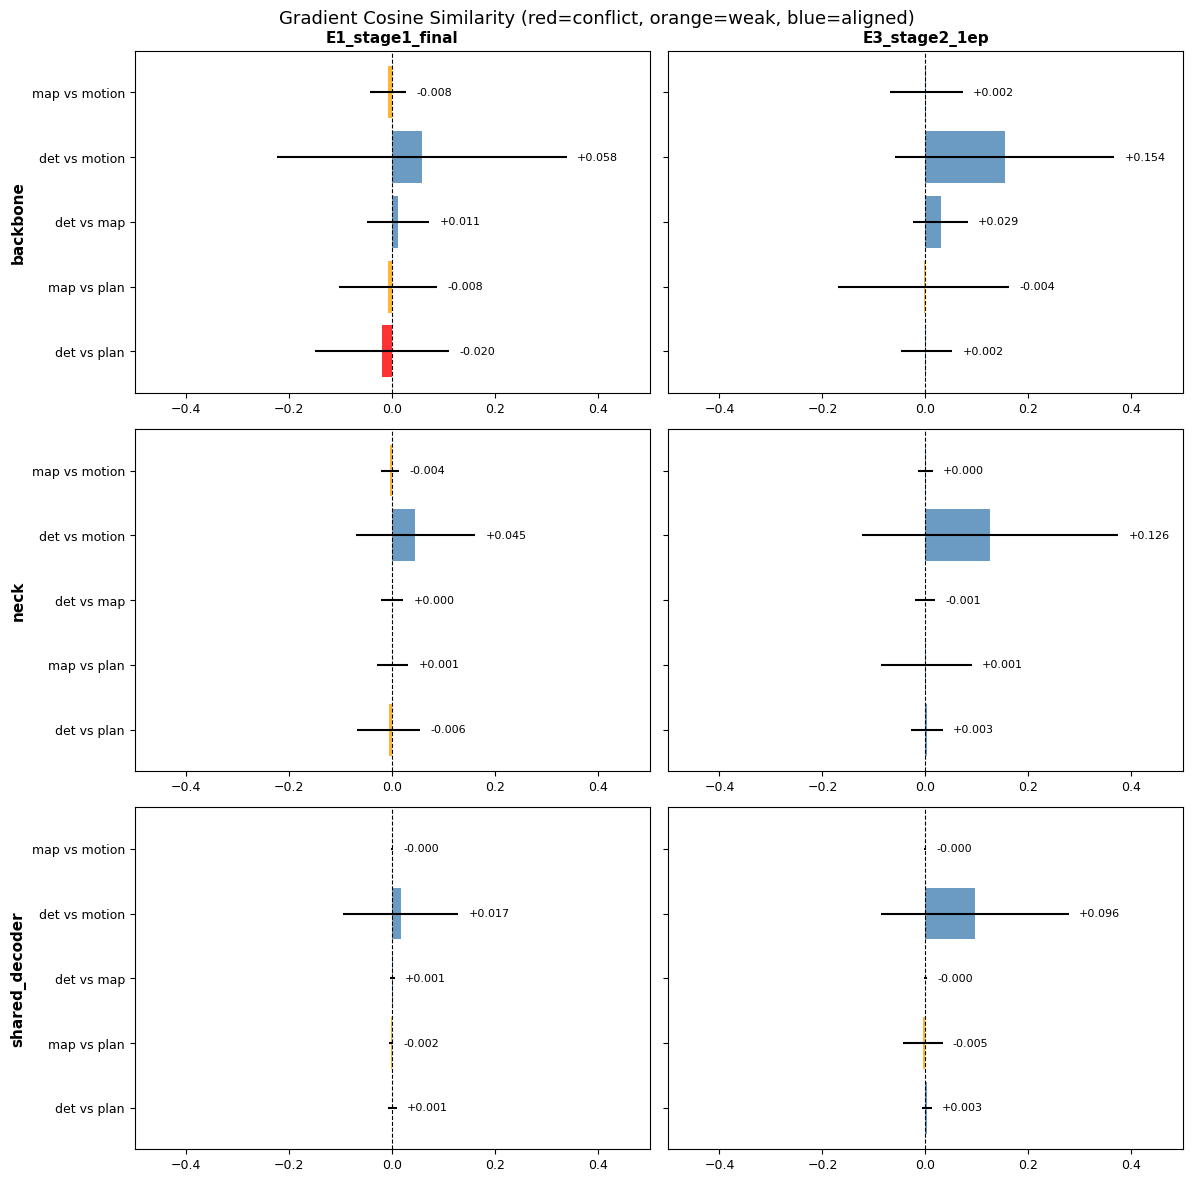

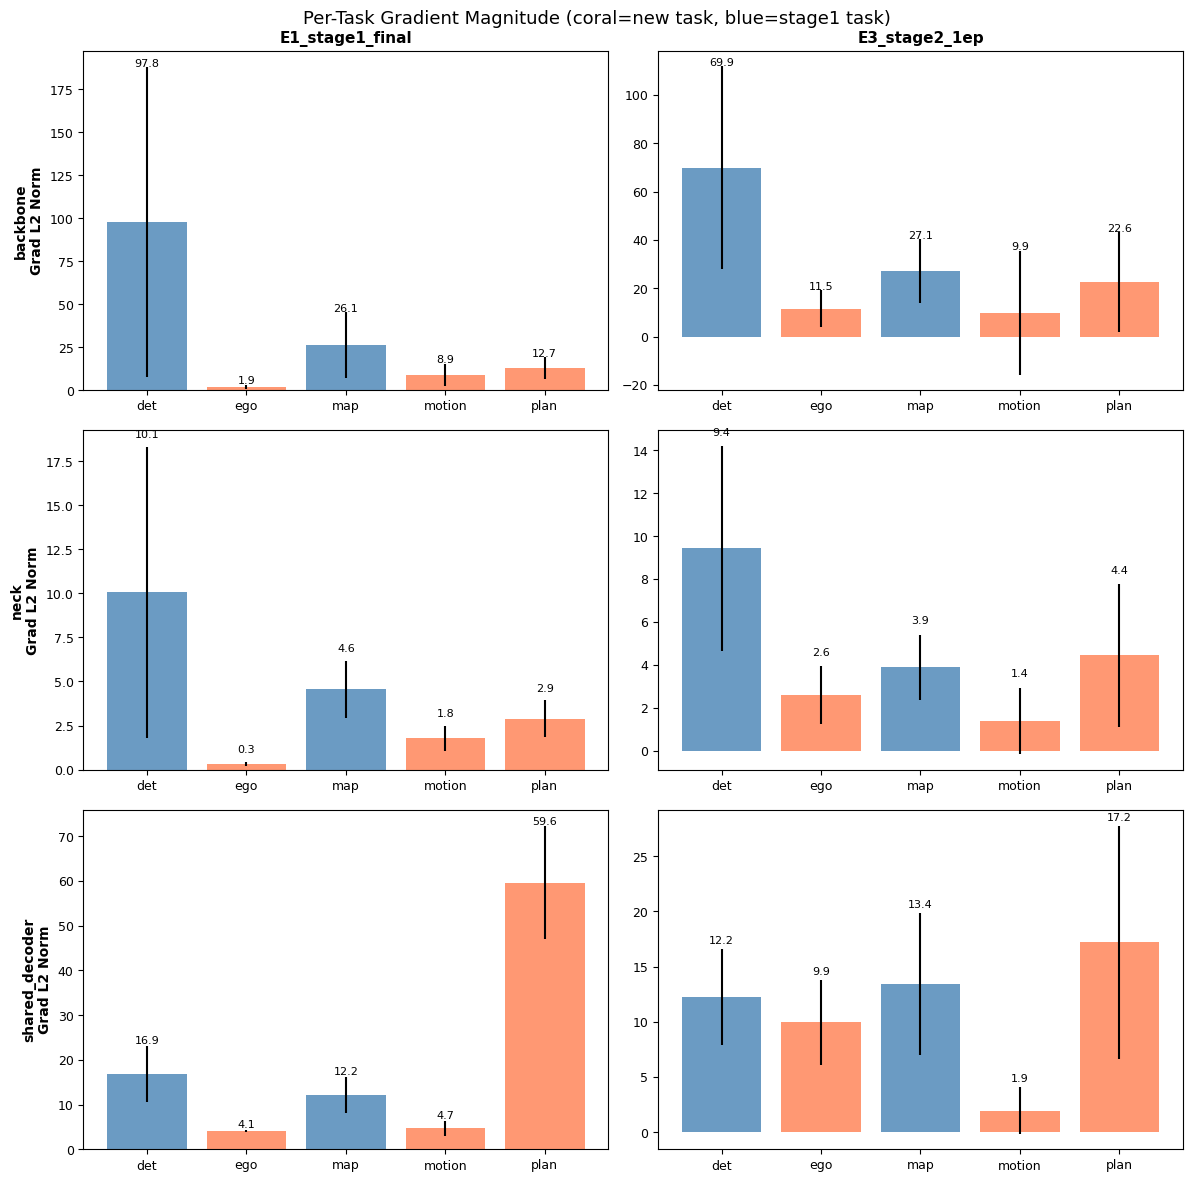


  E1_stage1_final

  [backbone]
  Pair                   cos (mean±std)         Conflict?
  -------------------------------------------------------
  det vs plan            -0.0198 ± 0.1301     !! YES
  map vs plan            -0.0078 ± 0.0957     ~ weak
  det vs map             +0.0113 ± 0.0605     No
  det vs motion          +0.0579 ± 0.2812     No
  map vs motion          -0.0080 ± 0.0357     ~ weak

  Task         Grad Norm       Loss Val        Norm Ratio vs det
  -------------------------------------------------------
  det          97.84           18.1479         1.00x
  ego          1.86            7.0796          0.02x
  map          26.15           3.2394          0.27x
  motion       8.86            5.1253          0.09x
  plan         12.65           6.3184          0.13x

  [neck]
  Pair                   cos (mean±std)         Conflict?
  -------------------------------------------------------
  det vs plan            -0.0062 ± 0.0612     ~ weak
  map vs plan            +

In [11]:
# ===================== 1-2. 시각화: Cosine Similarity + Grad Norm =====================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 9

FOCUS_PAIRS = ['det vs plan', 'map vs plan', 'det vs map', 'det vs motion', 'map vs motion']
ckpt_names = list(CKPTS.keys())

# --- (A) Cosine Similarity heatmap ---
fig, axes = plt.subplots(len(ANALYSIS_GROUPS), len(ckpt_names),
                         figsize=(6 * len(ckpt_names), 4 * len(ANALYSIS_GROUPS)),
                         squeeze=False)

for col, ckpt_name in enumerate(ckpt_names):
    for row, group_name in enumerate(ANALYSIS_GROUPS):
        ax = axes[row][col]
        cos_sims = results[ckpt_name][group_name]['cos_sims']

        pairs = [p for p in FOCUS_PAIRS if p in cos_sims]
        means = [np.mean(cos_sims[p]) for p in pairs]
        stds = [np.std(cos_sims[p]) for p in pairs]
        colors = ['red' if m < -0.01 else ('orange' if m < 0 else 'steelblue') for m in means]

        ax.barh(range(len(pairs)), means, xerr=stds, color=colors, alpha=0.8)
        ax.set_yticks(range(len(pairs)))
        ax.set_yticklabels(pairs if col == 0 else [], fontsize=9)
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xlim(-0.5, 0.5)
        for i, (m, s) in enumerate(zip(means, stds)):
            ax.text(max(m + s + 0.02, 0.02), i, f'{m:+.3f}', va='center', fontsize=8)

        if row == 0:
            ax.set_title(ckpt_name, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(group_name, fontsize=11, fontweight='bold')

fig.suptitle('Gradient Cosine Similarity (red=conflict, orange=weak, blue=aligned)', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/gradient_conflict_e3.png', dpi=150, bbox_inches='tight')
plt.show()

# --- (B) Gradient Norm 비교 ---
fig2, axes2 = plt.subplots(len(ANALYSIS_GROUPS), len(ckpt_names),
                           figsize=(6 * len(ckpt_names), 4 * len(ANALYSIS_GROUPS)),
                           squeeze=False)

for col, ckpt_name in enumerate(ckpt_names):
    for row, group_name in enumerate(ANALYSIS_GROUPS):
        ax = axes2[row][col]
        grad_norms = results[ckpt_name][group_name]['grad_norms']
        tasks = sorted(grad_norms.keys())
        means = [np.mean(grad_norms[t]) for t in tasks]
        stds = [np.std(grad_norms[t]) for t in tasks]
        colors = ['coral' if t in ['motion', 'plan', 'ego'] else 'steelblue' for t in tasks]

        ax.bar(tasks, means, yerr=stds, color=colors, alpha=0.8)
        for i, (m, s) in enumerate(zip(means, stds)):
            ax.text(i, m + s + 0.5, f'{m:.1f}', ha='center', fontsize=8)

        if row == 0:
            ax.set_title(ckpt_name, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{group_name}\nGrad L2 Norm', fontsize=10, fontweight='bold')

fig2.suptitle('Per-Task Gradient Magnitude (coral=new task, blue=stage1 task)', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/gradient_norms_e3.png', dpi=150, bbox_inches='tight')
plt.show()

# --- (C) 숫자 요약 ---
for ckpt_name in ckpt_names:
    print(f"\n{'='*70}")
    print(f"  {ckpt_name}")
    print(f"{'='*70}")
    for group_name in ANALYSIS_GROUPS:
        r = results[ckpt_name][group_name]
        print(f"\n  [{group_name}]")
        print(f"  {'Pair':<22} {'cos (mean±std)':<22} {'Conflict?'}")
        print(f"  {'-'*55}")
        for pair in FOCUS_PAIRS:
            if pair in r['cos_sims']:
                m = np.mean(r['cos_sims'][pair])
                s = np.std(r['cos_sims'][pair])
                tag = "!! YES" if m < -0.01 else ("~ weak" if m < 0 else "No")
                print(f"  {pair:<22} {m:+.4f} ± {s:.4f}     {tag}")

        print(f"\n  {'Task':<12} {'Grad Norm':<15} {'Loss Val':<15} {'Norm Ratio vs det'}")
        print(f"  {'-'*55}")
        det_norm = np.mean(r['grad_norms'].get('det', [1]))
        for task in sorted(r['grad_norms'].keys()):
            gn = np.mean(r['grad_norms'][task])
            lv = np.mean(r['loss_vals'].get(task, [0]))
            ratio = gn / det_norm if det_norm > 0 else 0
            print(f"  {task:<12} {gn:<15.2f} {lv:<15.4f} {ratio:.2f}x")

## 2. Representation Drift 측정

Gradient conflict/domination과는 독립적인 문제: 공유 파라미터가 새 task에 맞춰 변하면 기존 head가 기대하는 feature 분포와 mismatch.

**방법**: E1 ckpt(stage1 끝) vs E3 1ep ckpt의 backbone/neck/decoder feature 출력을 같은 입력에 대해 비교.
- Feature cosine similarity: 1에 가까우면 drift 없음, 낮으면 drift 큼
- L2 distance: 절대 크기
- 각 layer group에서 어디가 가장 많이 변했는지

In [12]:
# ===================== 2-1. Weight Drift: E1 vs E3 파라미터 직접 비교 =====================
# Feature 출력 비교는 모델 내부 hook이 필요해서 복잡하므로,
# 더 직접적인 지표: 파라미터 자체가 얼마나 변했는가 (weight space drift)

print("Loading both checkpoints for weight drift comparison...")

ckpt_e1 = torch.load(E1_CKPT, map_location='cpu')
ckpt_e3 = torch.load(E3_1EP_CKPT, map_location='cpu')
sd_e1 = ckpt_e1['state_dict'] if 'state_dict' in ckpt_e1 else ckpt_e1
sd_e3 = ckpt_e3['state_dict'] if 'state_dict' in ckpt_e3 else ckpt_e3

# 공통 key만 비교
common_keys = set(sd_e1.keys()) & set(sd_e3.keys())
print(f"Common parameters: {len(common_keys)}")

# 파라미터 그룹별 drift 측정
group_filters = {
    'img_backbone': lambda n: n.startswith('img_backbone'),
    'img_neck': lambda n: n.startswith('img_neck'),
    'depth_branch': lambda n: n.startswith('depth_branch'),
    'shared_decoder (layers)': lambda n: 'onedecoder_head.layers.' in n,
    'det_specific': lambda n: any(k in n for k in ['det_instance_bank', 'det_anchor_encoder', 'det_deformable', 'det_refine']),
    'map_specific': lambda n: any(k in n for k in ['map_instance_bank', 'map_anchor_encoder', 'map_deformable', 'map_refine']),
    'plan_specific': lambda n: any(k in n for k in ['plan_instance_bank', 'plan_anchor_encoder', 'plan_deformable', 'plan_refine']),
    'ego_specific': lambda n: any(k in n for k in ['ego_instance_bank', 'ego_deformable', 'ego_refine']),
}

print(f"\n{'Group':<30} {'Cosine Sim':<14} {'Rel L2 Drift':<14} {'# Params'}")
print("-" * 75)

drift_results = {}
for group_name, filter_fn in group_filters.items():
    keys = [k for k in common_keys if filter_fn(k)]
    if not keys:
        continue

    # 모든 파라미터를 하나의 벡터로 concat
    vec_e1 = torch.cat([sd_e1[k].float().flatten() for k in sorted(keys)])
    vec_e3 = torch.cat([sd_e3[k].float().flatten() for k in sorted(keys)])

    cos = F.cosine_similarity(vec_e1.unsqueeze(0), vec_e3.unsqueeze(0)).item()
    l2_dist = (vec_e1 - vec_e3).norm().item()
    l2_orig = vec_e1.norm().item()
    rel_drift = l2_dist / l2_orig if l2_orig > 0 else 0

    drift_results[group_name] = {'cos': cos, 'rel_l2': rel_drift, 'n_params': len(keys), 'n_elements': vec_e1.numel()}
    print(f"{group_name:<30} {cos:<14.6f} {rel_drift:<14.6f} {len(keys)}")

del ckpt_e1, ckpt_e3, sd_e1, sd_e3
torch.cuda.empty_cache()

Loading both checkpoints for weight drift comparison...
Common parameters: 1646

Group                          Cosine Sim     Rel L2 Drift   # Params
---------------------------------------------------------------------------
img_backbone                   1.000000       0.111111       318
img_neck                       0.999810       0.113810       32
depth_branch                   0.998794       0.058369       6
shared_decoder (layers)        0.994546       0.105529       204
det_specific                   0.999968       0.008071       367
map_specific                   0.999724       0.023504       244
plan_specific                  0.999987       0.111250       261
ego_specific                   0.999979       0.111338       146


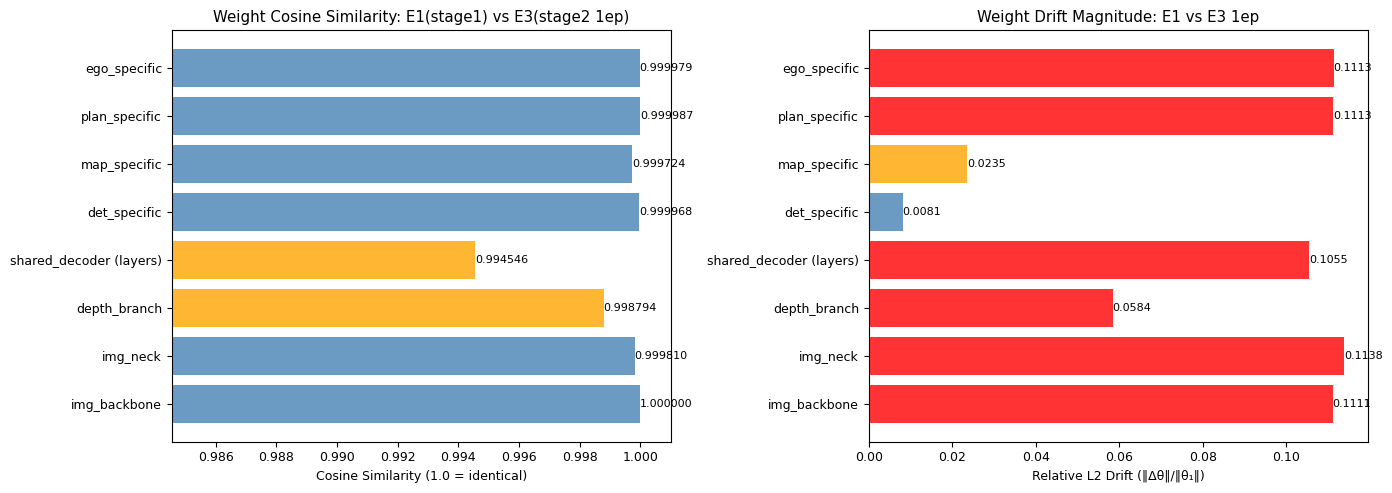

In [13]:
# ===================== 2-2. Weight Drift 시각화 =====================
import matplotlib.pyplot as plt

groups = list(drift_results.keys())
cos_vals = [drift_results[g]['cos'] for g in groups]
drift_vals = [drift_results[g]['rel_l2'] for g in groups]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cosine similarity (1.0 = no drift)
colors = ['red' if c < 0.99 else ('orange' if c < 0.999 else 'steelblue') for c in cos_vals]
ax1.barh(range(len(groups)), cos_vals, color=colors, alpha=0.8)
ax1.set_yticks(range(len(groups)))
ax1.set_yticklabels(groups)
ax1.set_xlabel('Cosine Similarity (1.0 = identical)')
ax1.set_title('Weight Cosine Similarity: E1(stage1) vs E3(stage2 1ep)')
ax1.set_xlim(min(cos_vals) - 0.01, 1.001)
for i, v in enumerate(cos_vals):
    ax1.text(v, i, f'{v:.6f}', va='center', fontsize=8)

# Relative L2 drift
colors2 = ['red' if d > 0.05 else ('orange' if d > 0.01 else 'steelblue') for d in drift_vals]
ax2.barh(range(len(groups)), drift_vals, color=colors2, alpha=0.8)
ax2.set_yticks(range(len(groups)))
ax2.set_yticklabels(groups)
ax2.set_xlabel('Relative L2 Drift (‖Δθ‖/‖θ₁‖)')
ax2.set_title('Weight Drift Magnitude: E1 vs E3 1ep')
for i, v in enumerate(drift_vals):
    ax2.text(v, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/weight_drift_e3.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 종합 진단

결과 해석 가이드:

| 관찰 | 진단 | 대응 |
|------|------|------|
| cos < -0.1 (backbone/decoder) | **Gradient Conflict** | FAMO, CAGrad |
| plan grad norm >> det grad norm | **Gradient Domination** | plan loss weight 줄이기, GradNorm |
| Weight drift가 det_specific에서 크다 | **Representation Drift** | LwF, L2-SP, EWC |
| 위 모두 약하지만 성능은 떨어짐 | **2차 효과 / curvature** | 더 긴 warmup, 작은 LR |

In [14]:
# ===================== 3. 종합 진단 출력 =====================

print("=" * 70)
print("  DIAGNOSIS SUMMARY")
print("=" * 70)

# E1 ckpt 기준 (stage2 시작 시점)
ckpt_name = 'E1_stage1_final'
if ckpt_name in results:
    print(f"\n--- {ckpt_name} 기준 ---\n")

    # 1. Conflict 진단
    print("[1] Gradient Conflict")
    worst_conflict = None
    for group_name in ANALYSIS_GROUPS:
        r = results[ckpt_name][group_name]
        for pair, vals in r['cos_sims'].items():
            m = np.mean(vals)
            if m < -0.01:
                print(f"  !! {group_name}: {pair} = {m:+.4f}")
                if worst_conflict is None or m < worst_conflict[2]:
                    worst_conflict = (group_name, pair, m)
    if worst_conflict is None:
        print("  No significant conflict detected.")
    else:
        print(f"  >> Worst: {worst_conflict[0]}/{worst_conflict[1]} = {worst_conflict[2]:+.4f}")

    # 2. Domination 진단
    print("\n[2] Gradient Domination")
    for group_name in ANALYSIS_GROUPS:
        r = results[ckpt_name][group_name]
        norms = {t: np.mean(v) for t, v in r['grad_norms'].items()}
        det_n = norms.get('det', 1)
        for task in ['plan', 'motion', 'ego']:
            if task in norms and det_n > 0:
                ratio = norms[task] / det_n
                if ratio > 2.0:
                    print(f"  !! {group_name}: {task} grad norm = {ratio:.1f}x det")
                elif ratio > 0.5:
                    print(f"     {group_name}: {task} grad norm = {ratio:.1f}x det (moderate)")

# 3. Drift 진단
print("\n[3] Representation Drift (E1 → E3 1ep)")
for group_name, dr in drift_results.items():
    cos = dr['cos']
    rel = dr['rel_l2']
    if cos < 0.99:
        print(f"  !! {group_name}: cos={cos:.6f}, rel_drift={rel:.4f} (SIGNIFICANT)")
    elif cos < 0.999:
        print(f"     {group_name}: cos={cos:.6f}, rel_drift={rel:.4f} (moderate)")
    else:
        print(f"     {group_name}: cos={cos:.6f}, rel_drift={rel:.4f} (minimal)")

print("\n" + "=" * 70)

  DIAGNOSIS SUMMARY

--- E1_stage1_final 기준 ---

[1] Gradient Conflict
  !! backbone: det vs plan = -0.0198
  !! neck: ego vs plan = -0.0553
  !! shared_decoder: ego vs plan = -0.0315
  >> Worst: neck/ego vs plan = -0.0553

[2] Gradient Domination
  !! shared_decoder: plan grad norm = 3.5x det

[3] Representation Drift (E1 → E3 1ep)
     img_backbone: cos=1.000000, rel_drift=0.1111 (minimal)
     img_neck: cos=0.999810, rel_drift=0.1138 (minimal)
     depth_branch: cos=0.998794, rel_drift=0.0584 (moderate)
     shared_decoder (layers): cos=0.994546, rel_drift=0.1055 (moderate)
     det_specific: cos=0.999968, rel_drift=0.0081 (minimal)
     map_specific: cos=0.999724, rel_drift=0.0235 (minimal)
     plan_specific: cos=0.999987, rel_drift=0.1113 (minimal)
     ego_specific: cos=0.999979, rel_drift=0.1113 (minimal)



In [15]:
# DEBUG: ego loss 원인 추적
model_dbg, loader_dbg = build_model_and_loader(E3_1EP_CKPT)
loader_iter = iter(loader_dbg)
losses_dbg, img_dbg, data_dbg = forward_one_batch(model_dbg, loader_iter)

print("=== ego 관련 loss entries ===")
for k, v in sorted(losses_dbg.items()):
    if 'ego' in k:
        print(f"  {k}: value={v}, type={type(v).__name__}, is_tensor={isinstance(v, torch.Tensor)}")

print("\n=== ego 관련 data keys ===")
for k in sorted(data_dbg.keys()):
    if 'ego' in k or 'status' in k:
        v = data_dbg[k]
        if isinstance(v, torch.Tensor):
            print(f"  {k}: shape={v.shape}, all_zero={torch.all(v==0).item()}, sum={v.sum().item():.4f}")
        else:
            print(f"  {k}: type={type(v).__name__}, val={v}")

del model_dbg, loader_dbg
torch.cuda.empty_cache()


/home/kyungmin/anaconda3/envs/hipad/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '


load checkpoint from local path: ./work_dirs/exp/E3_E1_stage2_6ep/iter_2344.pth
{'version': 'v1.0-trainval'}
=== ego 관련 loss entries ===
  ego_loss_status: value=2.5771355628967285, type=Tensor, is_tensor=True

=== ego 관련 data keys ===
  ego_status: shape=torch.Size([1, 6]), all_zero=False, sum=9.1731
  ego_status_mask: shape=torch.Size([1, 6]), all_zero=False, sum=6.0000
  gt_ego_fut_cmd: shape=torch.Size([1, 3]), all_zero=False, sum=1.0000
  gt_ego_fut_masks: shape=torch.Size([1, 6]), all_zero=False, sum=6.0000
  gt_ego_fut_masks_2hz: shape=torch.Size([1, 6]), all_zero=False, sum=6.0000
  gt_ego_fut_trajs: shape=torch.Size([1, 6, 2]), all_zero=False, sum=28.4793
  gt_ego_fut_trajs_2hz: shape=torch.Size([1, 6, 2]), all_zero=False, sum=28.4793
